YEHAASARY KM

CB.SC.P2AIE25032

Diabetes Dataset (Regression)

Source: sklearn built-in dataset

Task: Predict disease progression

Features: BMI, Blood Pressure, Glucose, Age, etc.

Ideal for PDP because relationships are non-linear and numeric.

##IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay, partial_dependence


##LOAD DATASET

In [ ]:
from sklearn.datasets import load_diabetes

# Load diabetes dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Features and target
X = df.drop(columns="target")
y = df["target"]

print(X.columns)

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')


##TRAIN MODEL

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

print("R² Score:", model.score(X_test, y_test))


R² Score: 0.44481138081448945


##1D PARTIAL DEPENDENCE PLOTS

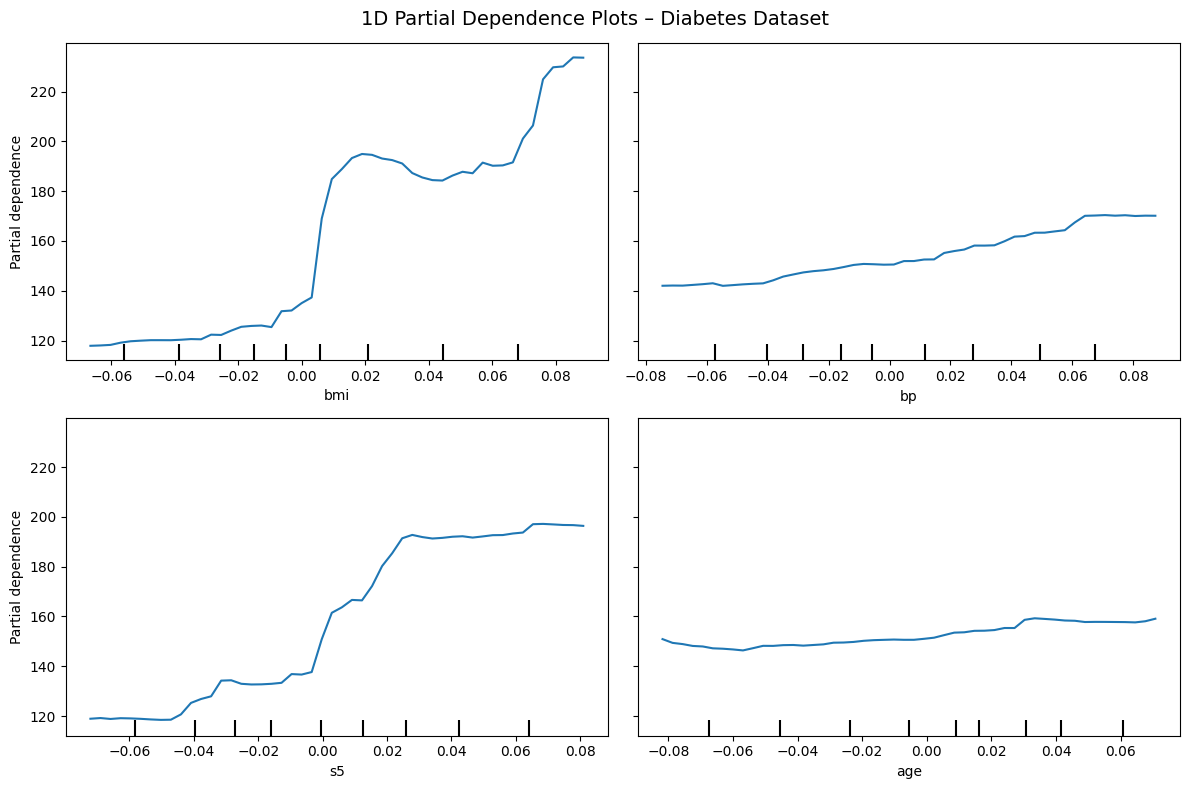

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features_1d = ['bmi', 'bp', 's5', 'age']

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features_1d,
    grid_resolution=50,
    ax=ax
)

plt.suptitle("1D Partial Dependence Plots – Diabetes Dataset", fontsize=14)
plt.tight_layout()
plt.show()

##2D PARTIAL DEPENDENCE PLOT

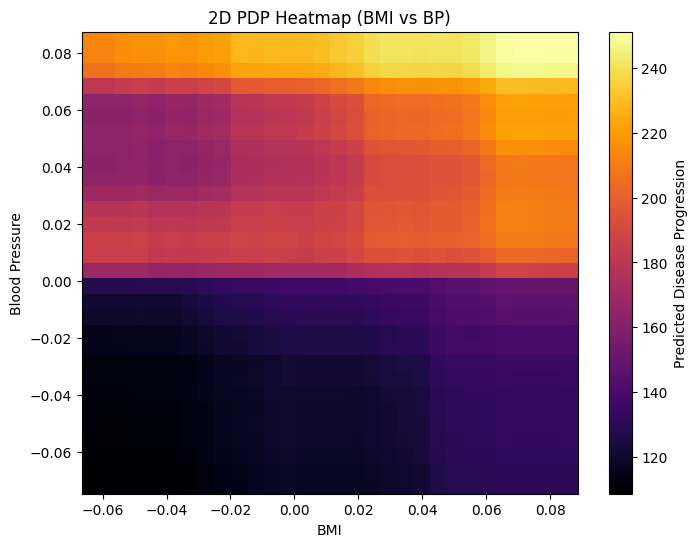

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(
    z_vals,
    origin='lower',
    aspect='auto',
    cmap='inferno',
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()]
)

plt.colorbar(label="Predicted Disease Progression")
plt.xlabel("BMI")
plt.ylabel("Blood Pressure")
plt.title("2D PDP Heatmap (BMI vs BP)")
plt.show()


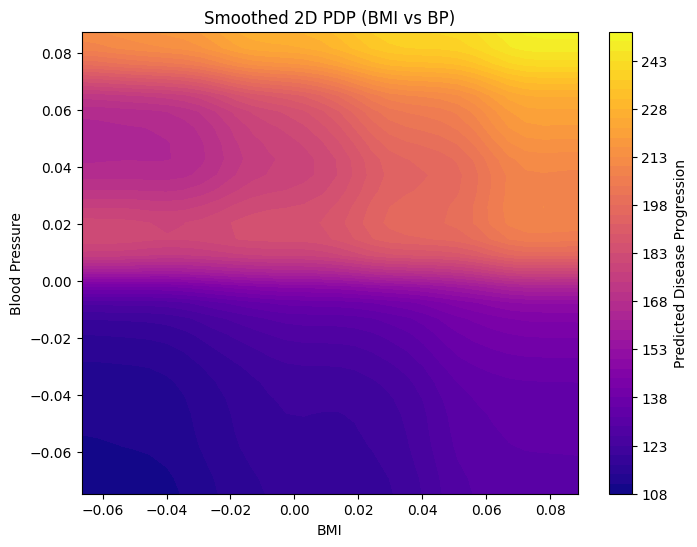

In [ ]:
from scipy.ndimage import gaussian_filter

# Smooth the PDP surface
z_smooth = gaussian_filter(z_vals, sigma=1.2)

plt.figure(figsize=(8,6))
plt.contourf(
    Xg, Yg, z_smooth,
    levels=50,
    cmap='plasma'
)

plt.colorbar(label="Predicted Disease Progression")
plt.xlabel("BMI")
plt.ylabel("Blood Pressure")
plt.title("Smoothed 2D PDP (BMI vs BP)")
plt.show()


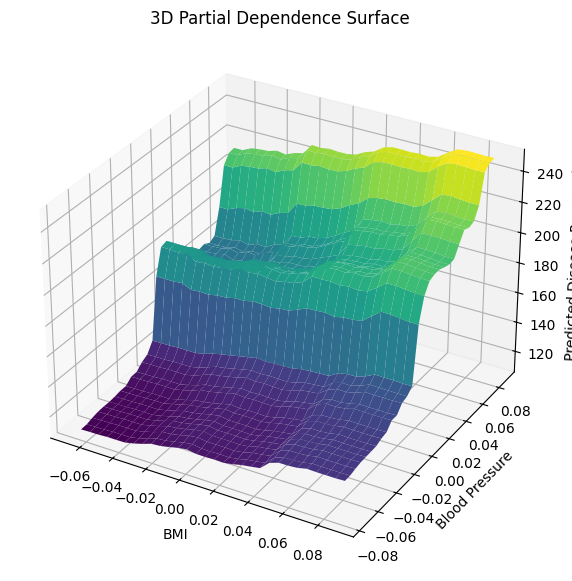

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    Xg, Yg, z_vals,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel("BMI")
ax.set_ylabel("Blood Pressure")
ax.set_zlabel("Predicted Disease Progression")
ax.set_title("3D Partial Dependence Surface")
plt.show()


##Heat map

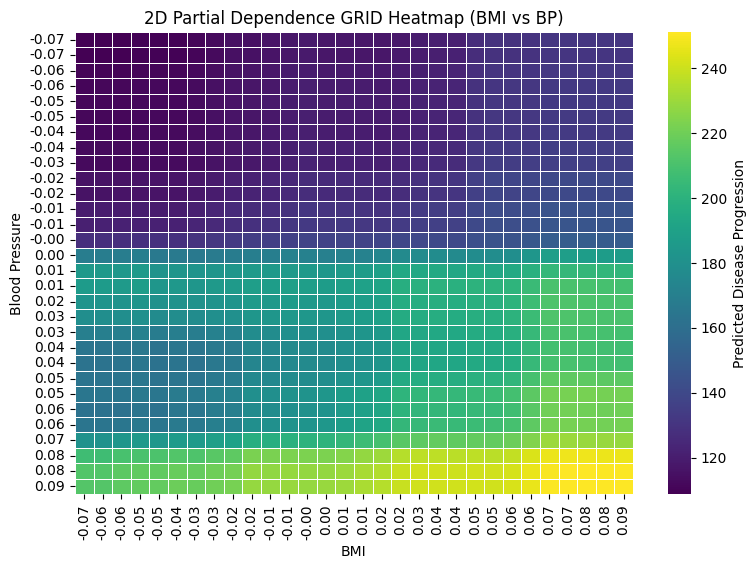

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Convert PDP values to DataFrame (grid)
heatmap_df = pd.DataFrame(
    z_vals,
    index=[f"{v:.2f}" for v in y_vals],
    columns=[f"{v:.2f}" for v in x_vals]
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    heatmap_df,
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Predicted Disease Progression"}
)

plt.xlabel("BMI")
plt.ylabel("Blood Pressure")
plt.title("2D Partial Dependence GRID Heatmap (BMI vs BP)")
plt.show()


**5 KEY UNDERSTANDINGS FROM THE PDPs**

**1.BMI is the most influential feature**


Higher BMI leads to a strong increase in predicted disease progression.

**2.Blood pressure has a positive but moderate effect**


PDP shows gradual increase in disease severity with rising BP.

**3.BMI and BP interact non-linearly**


High BMI combined with high BP results in the highest disease risk.

**4.Age has a weaker marginal effect**


Disease progression is more influenced by physiological variables than age alone.

**5.Cholesterol-related feature (s5) shows threshold behavior**

After a certain level, disease progression rises sharply.

##Breast Cancer Wisconsin Dataset

Source: sklearn

Task: Classification

Target: malignant / benign

Why this dataset is good:

Fully numeric

Medical relevance

Very common in exams

Works perfectly with PDP

IMPORTS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import partial_dependence


LOAD DATASET

In [ ]:
# Load dataset
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame

X = df.drop(columns="target")
y = df["target"]   # 0 = malignant, 1 = benign

print(X.columns)
print(X_train.columns.tolist())



Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'sy

TRAIN MODEL

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))


Accuracy: 0.9649122807017544


COMPUTE 1D PDP VALUES

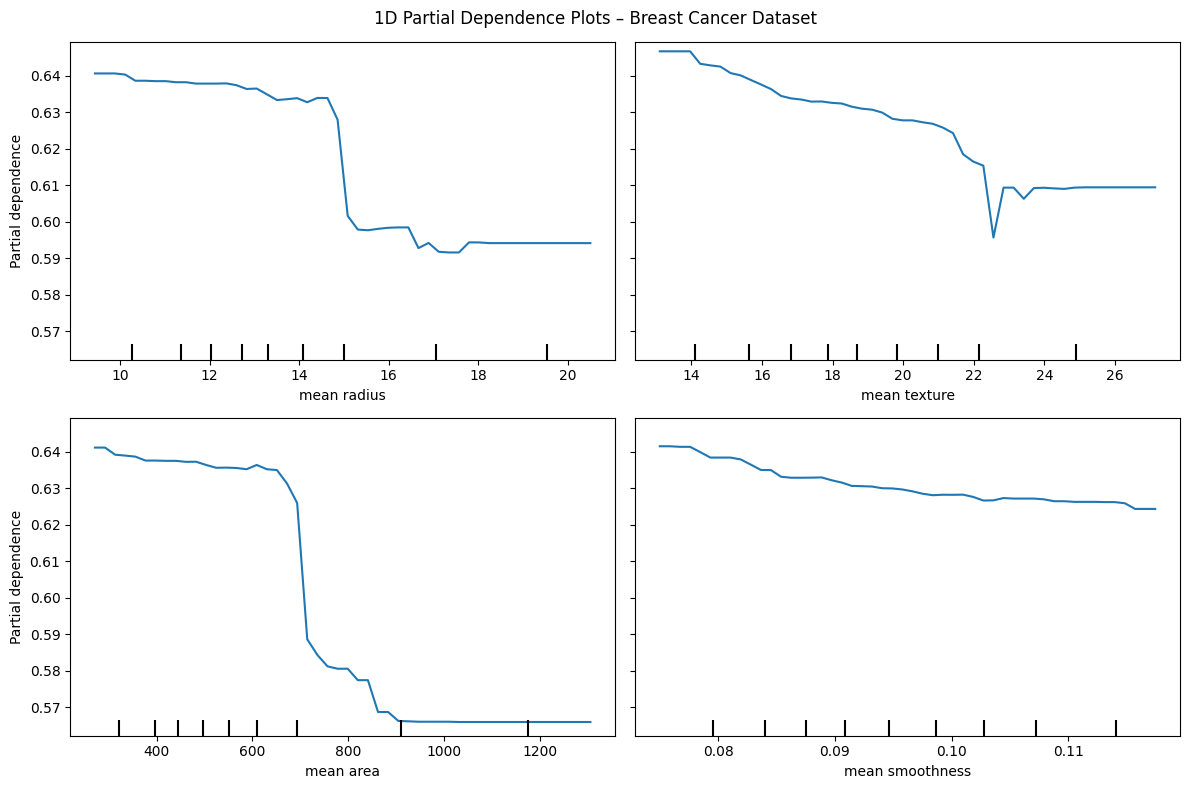

In [ ]:
features_1d = ['mean radius', 'mean texture', 'mean area', 'mean smoothness']

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features_1d,
    grid_resolution=50,
    ax=ax
)

plt.suptitle("1D Partial Dependence Plots – Breast Cancer Dataset")
plt.tight_layout()
plt.show()


COMPUTE 2D PDP VALUES

In [ ]:
from sklearn.inspection import partial_dependence
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Use column indices (safest)
idx_radius  = X_train.columns.get_loc('mean radius')
idx_texture = X_train.columns.get_loc('mean texture')

# Compute PDP
pdp_results = partial_dependence(
    model,
    X_train,
    features=[(idx_radius, idx_texture)],
    grid_resolution=20
)

#  USE grid_values (NOT values)
x_vals = pdp_results['grid_values'][0]
y_vals = pdp_results['grid_values'][1]

# Classification → only index 0 exists
z_vals = pdp_results['average'][0].reshape(len(x_vals), len(y_vals))


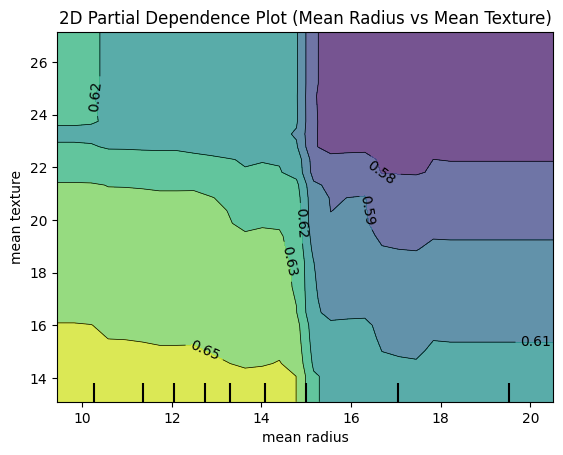

In [ ]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=[('mean radius', 'mean texture')],
    grid_resolution=30
)

plt.title("2D Partial Dependence Plot (Mean Radius vs Mean Texture)")
plt.show()


GRID HEAT MAP

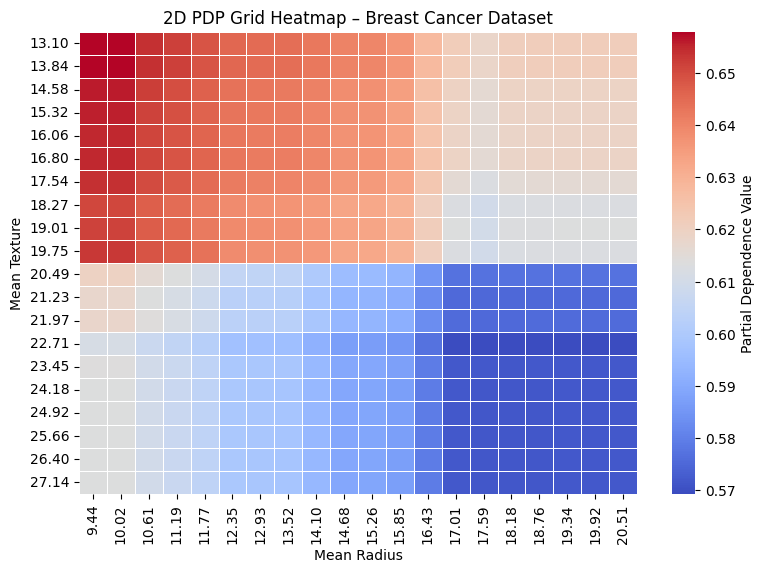

In [ ]:
heatmap_df = pd.DataFrame(
    z_vals,
    index=[f"{v:.2f}" for v in y_vals],
    columns=[f"{v:.2f}" for v in x_vals]
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    linewidths=0.4,
    cbar_kws={"label": "Partial Dependence Value"}
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("2D PDP Grid Heatmap – Breast Cancer Dataset")
plt.show()


5 UNDERSTANDINGS FROM THIS GRID HEAT MAP


1.Mean radius has a strong influence on tumor classification

Larger radius values significantly reduce the probability of benign tumors.

2.Texture interacts non-linearly with radius

For high texture values, even moderate radius increases malignancy risk.

3.Low radius and low texture regions correspond to benign tumors

Clear low-risk zone visible in the heatmap.

4.Decision boundaries are non-linear

The grid structure shows abrupt probability changes, justifying tree-based models.

5.Feature interaction is critical for medical diagnosis

Neither radius nor texture alone explains malignancy; their joint effect matters.